<a href="https://colab.research.google.com/github/RicardoTL75/Module_5_AI/blob/main/M5_1_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de clase 1 — Transfer learning con ResNet-18

**Objetivo:** configurar y razonar sobre tres regímenes de transfer learning usando el mismo ResNet-18 preentrenado:

1. **Sondeo lineal** — entrenar solo la nueva cabeza de clasificación.
2. **Afinación parcial** — entrenar la última etapa residual (`layer4`) y la nueva cabeza.
3. **Afinación completa** — entrenar toda la red.

No se requiere una ejecución completa de entrenamiento. El énfasis está en las decisiones que deben ser correctas antes de entrenar.

Al final del ejercicio, deberías poder:

- identificar el backbone y la cabeza específica de la tarea;
- controlar qué parámetros son entrenables sin reconstruir el modelo;
- verificar qué actualizará realmente el optimizador;
- preservar el preprocesamiento esperado por los pesos preentrenados;
- elegir un régimen inicial sensato según el tamaño del conjunto de datos y la similitud fuente–objetivo;
- reconocer cuándo el transfer learning puede requerir más que simplemente congelar o descongelar capas.

## 0. Transfer learning en una imagen

Un modelo preentrenado en una gran tarea fuente ya contiene representaciones visuales útiles.

\begin{equation}
\text{datos de origen} \rightarrow \boxed{\text{backbone preentrenado}} \rightarrow
\boxed{\text{cabeza fuente}}
\end{equation}

Para una nueva tarea objetivo, normalmente mantenemos el backbone, reemplazamos la cabeza fuente y decidimos cuánta parte de la red preentrenada actualizar:

\begin{equation}
\boxed{\text{backbone preentrenado}} \rightarrow
\boxed{\text{nueva cabeza de objetivo}}
\end{equation}

**Vocabulario**

- **Pesos preentrenados:** parámetros aprendidos en la tarea fuente.
- **Backbone / extractor de características:** la parte que produce representaciones reutilizables.
- **Cabeza:** capas específicas de salida para la tarea.
- **Fine-tuning:** continuar la optimización desde pesos preentrenados con datos de la tarea objetivo.
- **Transferencia negativa:** las características preentrenadas pueden resultar poco útiles cuando el problema fuente y el objetivo son demasiado diferentes.

La pregunta práctica no es “¿Debo siempre ajustar todo?” sino “¿Cuánta adaptación necesita la tarea objetivo?”

In [1]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary
torch.manual_seed(0)

NUM_CLASSES = 5
weights = ResNet18_Weights.DEFAULT

# Load the pretrained source model.
# If the weights are not cached, torchvision may download them once.
try:
    model = resnet18(weights=weights)
    pretrained_available = True
    print("Loaded pretrained ResNet-18 weights.")
except Exception as e:
    # The structural parts of the exercise still run, but this fallback is NOT transfer learning.
    print("Pretrained weights unavailable:", type(e).__name__)
    print("Using random weights only so the architecture exercises can still run.")
    model = resnet18(weights=None)
    pretrained_available = False

# ResNet-18 was pretrained with an ImageNet classification head.
# Replace only the task-specific head; this new layer starts from random initialization.
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

summary(model, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"])

print("Feature dimension entering the new head:", in_features)
print("Target classes:", NUM_CLASSES)
print("True transfer learning:", pretrained_available)

Loaded pretrained ResNet-18 weights.
Feature dimension entering the new head: 512
Target classes: 5
True transfer learning: True


### El preprocesamiento fuente es parte del modelo preentrenado

Las características preentrenadas se aprendieron bajo un pipeline de entrada particular. Un error común en transfer learning es reutilizar los pesos pero ignorar el preprocesamiento esperado por esos pesos.

`weights.transforms()` proporciona la pipeline de redimensionado, recorte y normalización asociada a estos pesos de ResNet-18. Para un conjunto de datos objetivo real, úsala como el preprocesamiento base salvo que el dominio objetivo requiera un cambio deliberado.

In [ ]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 1. Utilidades de entrenabilidad

Implementa las funciones a continuación.

Requisitos:

- cambiar `requires_grad` únicamente;
- no recrear el backbone;
- no reemplazar `model.fc` otra vez;
- cada régimen debe ser reproducible incluso si una celda anterior cambió la entrenabilidad.

Los alcances previstos son:

| Régimen | Módulos entrenables |
|---|---|
| Linear prob | `fc` únicamente |
| Afinación parcial | `layer4` + `fc` |
| Afinación completa | todos los parámetros |

In [ ]:
def freeze_all(model):
    """Freeze every learnable parameter."""
    for p in model.parameters():
        p.requires_grad = False
    return model


def unfreeze_head(model):
    """Configure a linear probe: only model.fc is trainable."""
    freeze_all(model)
    for p in model.fc.parameters():
        p.requires_grad = True
    return model


def unfreeze_layer4(model):
    """Configure partial fine-tuning: model.layer4 and model.fc are trainable."""
    freeze_all(model)
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True
    return model


def reset_trainability(model):
    """Make every parameter trainable."""
    for p in model.parameters():
        p.requires_grad = True
    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def trainable_parameter_names(model):
    return [name for name, p in model.named_parameters() if p.requires_grad]

## 2. Construye y compara los tres regímenes

Para cada régimen:

1. configura la entrenabilidad;
2. cuenta los parámetros totales y entrenables;
3. almacena el resultado en `results`;
4. inspecciona algunos nombres de parámetros entrenables.

Tu resultado debe cumplir:

\[
N_{\text{sondeo lineal}} < N_{\text{parcial}} < N_{\text{completo}}.
\]

El recuento total de parámetros debe permanecer constante. Solo debe cambiar el número de parámetros que reciben actualizaciones de gradiente.

In [ ]:
results = {}

# Regime 1: linear probe -- only the new head trains
unfreeze_head(model)
results["linear_probe"] = count_parameters(model)
print("linear_probe trainable names:", trainable_parameter_names(model))

# Regime 2: partial fine-tuning -- last residual stage + head
unfreeze_layer4(model)
results["partial_finetune"] = count_parameters(model)
print("partial_finetune trainable names (first 5):", trainable_parameter_names(model)[:5])

# Regime 3: full fine-tuning -- everything
reset_trainability(model)
results["full_finetune"] = count_parameters(model)
print("full_finetune trainable names (first 5):", trainable_parameter_names(model)[:5])
print()

for regime, counts in results.items():
    total, trainable = counts
    pct = 100.0 * trainable / total
    print(f"{regime:20s} total={total:>10,d}  trainable={trainable:>10,d}  ({pct:6.2f}%)")

linear_probe trainable names: ['fc.weight', 'fc.bias']
partial_finetune trainable names (first 5): ['layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias', 'layer4.0.conv2.weight', 'layer4.0.bn2.weight']
full_finetune trainable names (first 5): ['conv1.weight', 'bn1.weight', 'bn1.bias', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight']

linear_probe         total=11,179,077  trainable=     2,565  (  0.02%)
partial_finetune     total=11,179,077  trainable= 8,396,293  ( 75.11%)
full_finetune        total=11,179,077  trainable=11,179,077  (100.00%)


In [ ]:
# Optional self-check after you complete the previous cell.
if len(results) == 3:
    lp = results["linear_probe"][1]
    partial = results["partial_finetune"][1]
    full = results["full_finetune"][1]
    totals = {v[0] for v in results.values()}

    assert lp < partial < full, "Trainable parameter counts are not ordered as expected."
    assert len(totals) == 1, "The architecture should not change across regimes."
    print("Basic regime checks passed.")
else:
    print("Complete the three regimes first.")

Basic regime checks passed.


## 3. Verifica qué actualizará el optimizador

Congelar parámetros y configurar el optimizador son decisiones relacionadas pero distintas.

Un flujo de transfer learning limpio pasa solo los parámetros entrenables al optimizador. Esto hace explícito el alcance de las actualizaciones y evita llevar parámetros congelados en el estado del optimizador de manera silenciosa.

Configura la afinación parcial y crea un optimizador a partir de los parámetros entrenables únicamente.

Luego verifica:

$N_{\text{parámetros del optimizador}} = N_{\text{parámetros entrenables}}.$

**Extensión opcional:** usa una tasa de aprendizaje más pequeña para `layer4` preentrenado y una más grande para la cabeza `fc` inicializada aleatoriamente. Esto se conoce como configuración de tasas de aprendizaje discriminativas.

In [ ]:
# Configure partial fine-tuning first.
unfreeze_layer4(model)

# Collect only trainable parameters.
trainable_params = [p for p in model.parameters() if p.requires_grad]

# Create an optimizer using only trainable_params.
optimizer = torch.optim.AdamW(trainable_params, lr=1e-3)

# Verify the optimizer parameter count.
optimizer_param_count = sum(p.numel() for group in optimizer.param_groups for p in group["params"])

print("Trainable parameter count:", count_parameters(model)[1])
print("Optimizer parameter count:", optimizer_param_count)
assert optimizer_param_count == count_parameters(model)[1], \
    "optimizer parameter count must equal the trainable parameter count"

# Optional extension:
# optimizer = torch.optim.AdamW(
#     [
#         {"params": model.layer4.parameters(), "lr": 1e-4},
#         {"params": model.fc.parameters(), "lr": 1e-3},
#     ],
#     weight_decay=1e-4,
# )

Trainable parameter count: 8396293
Optimizer parameter count: 8396293


## 4. Comprobación de sanity del forward pass

Cambiar la entrenabilidad no debe alterar la compatibilidad de los tensores. El modelo debería seguir mapeando un batch RGB a cinco logits por imagen.

Un forward pass verifica la arquitectura, no si tu estrategia de transfer learning es estadísticamente buena.

In [ ]:
model.eval()

# Match the input's device to wherever model currently lives (CPU or GPU) --
# avoids a device-mismatch error if a later cell already moved `model` to "cuda".
device_check = next(model.parameters()).device
x = torch.randn(2, 3, 224, 224, device=device_check)

with torch.no_grad():
    y = model(x)

print("Input shape :", tuple(x.shape))
print("Output shape:", tuple(y.shape))

assert y.shape == (2, NUM_CLASSES)

Input shape : (2, 3, 224, 224)
Output shape: (2, 5)


## Una receta mínima de transfer learning para proyectos futuros

Usa esta secuencia como protocolo experimental predeterminado:

1. **Elige un modelo preentrenado compatible.** Haz coincidir la modalidad de entrada y la tarea lo más estrechamente posible.
2. **Usa el preprocesamiento fuente como base.**
3. **Reemplaza la cabeza específica de la tarea.**
4. **Entrena un sondeo lineal primero.** Es económico y te dice si la representación preentrenada ya es útil.
5. **Descongela progresivamente.** Pasa a la última etapa y luego al modelo completo solo si los resultados de validación justifican la flexibilidad adicional.
6. **Usa tasas de aprendizaje más pequeñas para los pesos preentrenados** que para una cabeza recién inicializada cuando sea apropiado.
7. **Compara regímenes en la misma partición de validación.** No uses el conjunto de prueba para elegir el régimen.
8. **Observa la transferencia negativa.** Si un modelo preentrenado cuidadosamente ajustado es consistentemente peor que una línea base comparable inicializada aleatoriamente, la representación fuente puede estar mal alineada con el dominio objetivo.

El mejor régimen es una elección empírica, pero el experimento debe estructurarse de modo que la razón para cambiar de régimen sea visible en el comportamiento de validación.

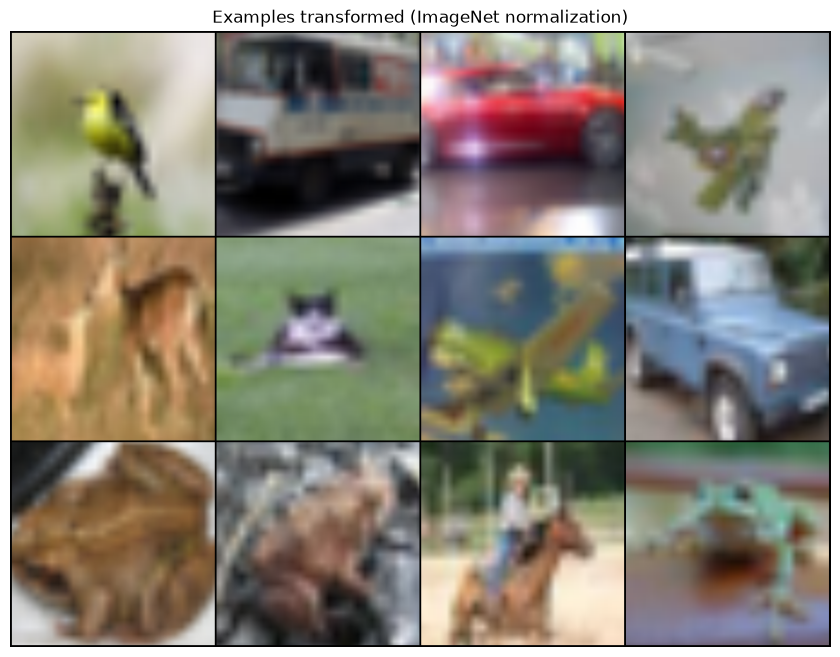

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Datos: CIFAR-10 con preprocesamiento compatible con ImageNet.
image_net_transform = weights.transforms()

train_ds = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=image_net_transform,
)

test_ds = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=image_net_transform,
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

# Mostrar una grilla de 3x4 ejemplos transformados
images, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
images_vis = images * std + mean
images_vis = torch.clamp(images_vis, 0, 1)

grid = make_grid(images_vis[:12], nrow=4, padding=2)
plt.figure(figsize=(12, 8))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Examples transformed (ImageNet normalization)")
plt.show()


linear_probe: final test accuracy = 0.775
partial_finetune: final test accuracy = 0.899
full_finetune: final test accuracy = 0.891


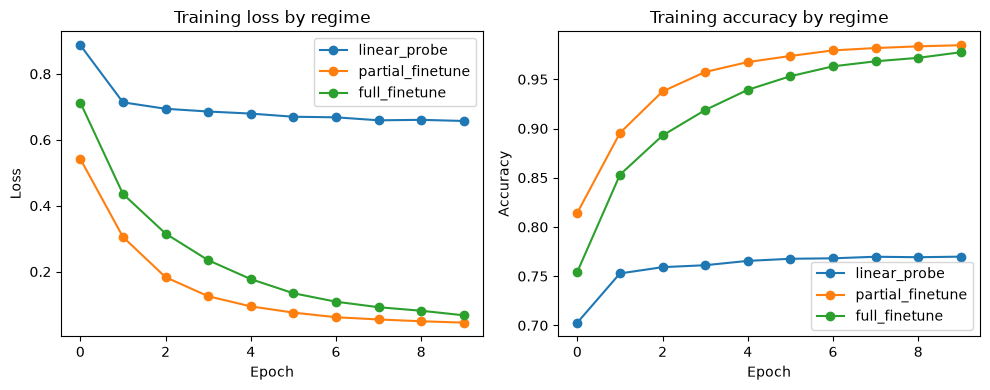

In [ ]:


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


def run_regime(name, setup_fn, epochs=10, lr=1e-3):
    cifar_model = resnet18(weights=weights)
    in_features = cifar_model.fc.in_features
    cifar_model.fc = nn.Linear(in_features, 10)
    cifar_model = cifar_model.to(device)

    setup_fn(cifar_model)

    trainable_params = [p for p in cifar_model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):
        cifar_model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            logits = cifar_model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * y.size(0)
            epoch_correct += (logits.argmax(1) == y).sum().item()
            epoch_total += y.size(0)

        avg_loss = epoch_loss / epoch_total
        avg_acc = epoch_correct / epoch_total
        losses.append(avg_loss)
        accuracies.append(avg_acc)

    acc = evaluate(cifar_model, test_loader)
    print(f"{name}: final test accuracy = {acc:.3f}")

    return losses, accuracies, acc


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = {}

for name, setup_fn in [
    ("linear_probe", lambda m: (freeze_all(m), unfreeze_head(m))[1]),
    ("partial_finetune", lambda m: (freeze_all(m), unfreeze_layer4(m))[1]),
    ("full_finetune", lambda m: reset_trainability(m)),
]:
    losses, accuracies, acc = run_regime(name, setup_fn, epochs=10, lr=1e-3)
    results[name] = {"loss": losses, "accuracy": accuracies, "test_acc": acc}

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for name, info in results.items():
    plt.plot(info["loss"], marker="o", label=name)
plt.title("Training loss by regime")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for name, info in results.items():
    plt.plot(info["accuracy"], marker="o", label=name)
plt.title("Training accuracy by regime")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()